In [17]:
import pandas as pd




df = pd.read_csv("retail_synthetique_tp3.csv")
df

,date,ville,magasin,transaction_id,client_id,sexe,age_client,categorie,produit,prix_unitaire,quantite,remise_pct,moyen_paiement
0,2024-06-12,Marrakech,D,T000001,C1177,F,42.0,Vetements,Sweat,761.72,2,15.0,Especes
1,2024-12-29,Fes,B,T000002,C1067,M,41.0,Alimentation,The,151.93,1,0.0,Especes
2,2024-06-24,Marrakech,A,T000003,C1216,M,27.0,Alimentation,Pates,99.02,1,0.0,Carte
3,2024-02-26,Marrakech,E,T000004,C1028,F,52.0,Maison,Coussin,835.89,1,10.0,Carte
4,2024-04-21,Marrakech,B,T000005,C1654,M,35.0,Beaute,Shampooing,666.02,3,10.0,Especes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3510,2024-11-08,Rabat,D,T000255,C1475,F,24.0,Vetements,T-shirt,685.12,2,5.0,Carte
3511,2024-03-29,Marrakech,E,T001888,C1631,M,35.0,Electronique,Souris,1481.26,1,0.0,Carte
3512,2024-11-01,Fes,B,T001720,C1269,F,25.0,Electronique,Clavier,1646.68,1,15.0,Carte
3513,2024-07-24,Tanger,D,T001148,C1442,F,48.0,Electronique,Smartphone,2357.40,1,0.0,Carte


In [18]:



df["date"] = pd.to_datetime(df["date"])
df["prix_unitaire"] = pd.to_numeric(df["prix_unitaire"])
df["quantite"] = pd.to_numeric(df["quantite"])
df["remise_pct"] = pd.to_numeric(df["remise_pct"])


df["montant"] = df["prix_unitaire"] * df["quantite"] * (1 - df["remise_pct"]/100)

print(df.head())

        date      ville magasin transaction_id client_id sexe  age_client  \
0 2024-06-12  Marrakech       D        T000001     C1177    F        42.0   
1 2024-12-29        Fes       B        T000002     C1067    M        41.0   
2 2024-06-24  Marrakech       A        T000003     C1216    M        27.0   
3 2024-02-26  Marrakech       E        T000004     C1028    F        52.0   
4 2024-04-21  Marrakech       B        T000005     C1654    M        35.0   

      categorie     produit  prix_unitaire  quantite  remise_pct  \
0     Vetements       Sweat         761.72         2        15.0   
1  Alimentation         The         151.93         1         0.0   
2  Alimentation       Pates          99.02         1         0.0   
3        Maison     Coussin         835.89         1        10.0   
4        Beaute  Shampooing         666.02         3        10.0   

  moyen_paiement   montant  
0        Especes  1294.924  
1        Especes   151.930  
2          Carte    99.020  
3          C

In [19]:
total_ventes = df["montant"].sum()
nb_transactions = df["transaction_id"].nunique()
nb_clients = df["client_id"].nunique()

print("Total ventes:", total_ventes)
print("Transactions:", nb_transactions)
print("Clients:", nb_clients)

Total ventes: 3431359.4524999997
Transactions: 3500
Clients: 694


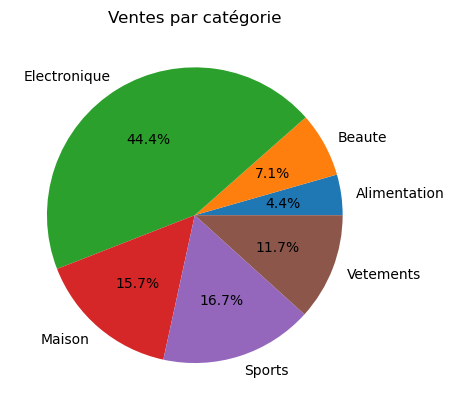

In [26]:
import matplotlib.pyplot as plt

cat = df.groupby("categorie")["montant"].sum()

cat.plot( kind="pie",autopct="%1.1f%%")
plt.title("Ventes par catégorie")
plt.ylabel("")
plt.show()

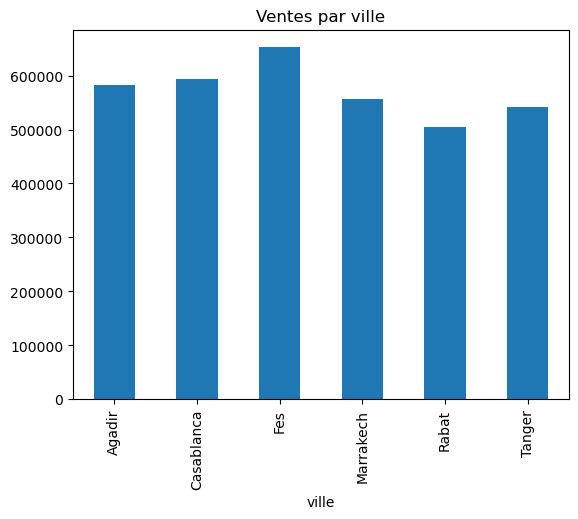

In [21]:
ville = df.groupby("ville")["montant"].sum()

ville.plot(kind="bar")
plt.title("Ventes par ville")
plt.show()

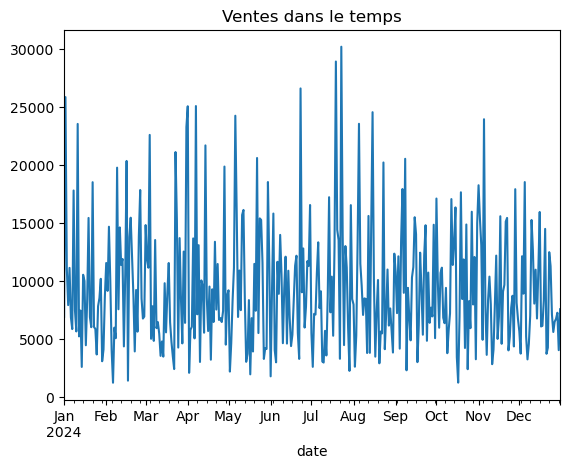

In [22]:
date = df.groupby("date")["montant"].sum()

date.plot()
plt.title("Ventes dans le temps")
plt.show()

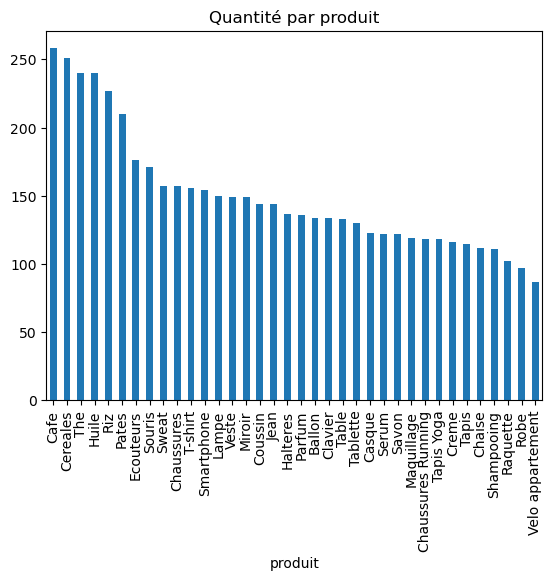

In [23]:
prod = df.groupby("produit")["quantite"].sum().sort_values(ascending=False)

prod.plot(kind="bar")
plt.title("Quantité par produit")
plt.show()

In [24]:
import plotly.express as px

fig = px.bar(df, x="ville", y="montant", color="categorie",
             title="Ventes par ville")
fig.show()